# **Atividade Avaliativa**  
## **Instituto de Computação**  
## **Universidade Estadual de Campinas \- UNICAMP**  
### **Curso: INF0087** Sistemas Inteligentes com Agentes Autônomos usando Grandes Modelos de Linguagem
### **Disciplina: Fundamentos de IA Generativa e PLN**

<br>

#### **1. Descrição da Atividade:**

* Realizar o ajuste fino:
  * Usar um LLM pequeno como base, ex.: TinyLlama/TinyLlama-1.1B-Chat-v1.0, google/gemma-3-1b-pt …  
  * Para fazer o fine-tuning supervisionado, utilizar o dataset “HuggingFaceTB/smoltalk2”, subconjunto/subset “SFT” e Split “sft\_smoltalk\_multilingual\_8languages\_lang\_5\_no\_think” (link: [https://huggingface.co/datasets/HuggingFaceTB/smoltalk2/viewer/SFT/smoltalk\_multilingual\_8languages\_lang\_5\_no\_think](https://huggingface.co/datasets/HuggingFaceTB/smoltalk2/viewer/SFT/smoltalk_multilingual_8languages_lang_5_no_think)). Dica: baixe o dataset no seu gdrive (ou local) para não precisar baixá-lo a cada execução.   
  * Aplicar QLoRA para realizar o ajuste fino de instruções.  
  * Ilustrar, com exemplos, as diferenças de geração entre o modelo de base e o ajustado.

<br>

#### **2. Critérios de Avaliação:**  
Os seguintes critérios serão considerados com igual peso (25% cada):

* Complexidade:   
  * Por ser uma atividade aberta, pode ser executada em diferentes níveis de complexidade. Por exemplo: um ajuste mais refinado dos parâmetros do QLoRA, uma análise comparativa dos modelos ou a filtragem dos dados de treinamento acrescentam nota, mas não são essenciais.     
* Completude:  
  * A atividade completa inclui carregar a LLM de base, carregar o conjunto de dados para o SFT, realizar o ajuste fino com QLoRA e verificar as diferenças nas respostas. O ajuste por preferências não faz parte da avaliação (não vale nota) e é uma atividade extra para os alunos que desejarem testar suas habilidades.    
* Corretude:  
  * Ausência de bugs, código eficiente e uso adequado da linguagem Python e bibliotecas.   
* Documentação:  
  * Os códigos deverão ser acompanhados de documentação que explique cada passo no notebook, ou seja, intercalando blocos de texto e de código. A documentação mais completa e clara receberá uma nota maior.

Importante: não fazem parte da avaliação aspectos que dependem apenas do poder computacional disponível (ex.: um conjunto de treinamento muito grande não influencia a nota).

<br>

#### **3. Modo de Entrega:**

**A atividade é Individual.**
Os alunos deverão copiar este notebook, incluir documentação (blocos de texto) e códigos, abaixo deste enunciado e também, as saídas de cada bloco de código.    

A entrega do notebook (.ipynb) será feita por meio da atividade no Google ClassRoom.  


## **Werner Denzin**
---
Para o desenvolvimento os seguines passos serão executados:
1.   Common  
2.   Loading Baseline Models (PT e IT)
3.   Fine-Tuning com QLoRA
4.   Comparações: PT x IT x Fine-Tuning
5.   Conclusão

### **1. Common**
---
* Funções e códigos gerais/comuns
* Devem ser reexecutadas a cada "bloco" (2, 3, 4) ❗

In [2]:
import subprocess
from google.colab import userdata

In [3]:
# Instalar bibliotecas necessárias
def install_libraries():
  !pip3 install -q -U bitsandbytes peft trl accelerate datasets transformers
  print('Bibliotecas instaladas!')

# Verificar Secrets e instanciar token para acesso ao Hugging Face
def load_secrets():
    tokens = {}
    for name in ("HF_TOKEN", "HF_TOKEN_WRITE"):
        value = userdata.get(name)
        if not value or not value.startswith("hf_"):
            raise RuntimeError(f"Falha ao carregar {name} — configure em Secrets do Colab")
        print(f"{name} configurado corretamente!")
        tokens[name] = value
    return tokens["HF_TOKEN"], tokens["HF_TOKEN_WRITE"]

# Verificar se há disponibilidade de GPU
def is_gpu_available():
  result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
  print('GPU ativa!' if result.returncode == 0 else 'GPU não detectada!')

# Setup
def setup():
  is_gpu_available()
  install_libraries()
  return load_secrets()

# Verificar distribuição de comprimentos em tokens
def count_tokens(dataset_split, tokenizer, sample_size=None):
    if sample_size is None:
        n = len(dataset_split)
    else:
        n = min(sample_size, len(dataset_split))
    subset = dataset_split.shuffle(seed=42).select(range(n))
    lengths = []
    for ex in tqdm(subset, desc="Contando tokens"):
        text = tokenizer.apply_chat_template(
            ex["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )
        ids = tokenizer(text, add_special_tokens=False)["input_ids"]
        lengths.append(len(ids))
    lengths = np.array(lengths)
    print(f"Comprimento dos exemplos (em tokens, n={len(lengths)}):")
    print(f"- min ....... {lengths.min()}")
    print(f"- mediana ... {int(np.median(lengths))}")
    print(f"- média ..... {int(lengths.mean())}")
    print(f"- p95 ....... {int(np.percentile(lengths, 95))}")
    print(f"- máximo .... {lengths.max()}")
    return lengths

### **2. Loading Baseline Models**
---
* Carregar `PT` e `IT`
* Gerar resultados com cada modelo para exemplificar comportamentos

In [3]:
HF_TOKEN, HF_TOKEN_WRITE = setup()

GPU ativa!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.9 MB/s eta 0:00:00
Bibliotecas instaladas!
HF_TOKEN configurado corretamente!
HF_TOKEN_WRITE configurado corretamente!


In [4]:
from transformers import pipeline
import torch

- `PT` | Pre-Trained
  * Carregar `google/gemma-3-1b-pt`
  * Objetivo prever o próximo token! Tem conhecimento geral da linguagem, mas não sabe seguir instruções

In [5]:
# Carregar o PT (gemma-3-1b-pt) com float16 (para economizar memória)
pipe_pt = pipeline(
  "text-generation",
  model="google/gemma-3-1b-pt",
  device="cuda",
  dtype=torch.bfloat16,
  token=HF_TOKEN
)
print("PT (gemma-3-1b-pt) carregado!")

config.json:   0%|          | 0.00/880 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

PT (gemma-3-1b-pt) carregado!


- `IT` | Instruction-Tuned
  * Carregar `google/gemma-3-1b-it`
  * Um modelo PT que foi treinado com pares de **instrução → resposta**, através de técnicas como **SFT** e **RLHF**
  * Entende uma conversa estruturada com: `system` (comportamento), `user` (user prompt) e `assistant` (LLM answer)


In [6]:
# Carregar o IT (gemma-3-1b-it) com float16 (para economizar memória)
pipe_it = pipeline(
  "text-generation",
  model="google/gemma-3-1b-it",
  device="cuda",
  dtype=torch.bfloat16,
  token=HF_TOKEN
)
print("IT (gemma-3-1b-it) carregado!")

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

IT (gemma-3-1b-it) carregado!


- `PT` x `IT`

In [7]:
# User prompt
PROMPT = "Explique em 128 caracteres: o que é \"Sistemas de IA Agênticos\""

# Adequando ao formato suportado pelo modelo IT
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": PROMPT
            }
        ]
    }
]

# Invoke PT
out_pt = pipe_pt(PROMPT, max_new_tokens=128, do_sample=False)

# Invoke IT
out_it = pipe_it(messages, max_new_tokens=128, do_sample=False)

print('\nPT:')
print(out_pt[0]["generated_text"])
print('\nIT:')
print(out_it[0]["generated_text"][-1]["content"])

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=128)


PT:
Explique em 128 caracteres: o que é "Sistemas de IA Agênticos" e como eles funcionam.

Explique em 128 caracteres: o que é "Sistemas de IA Agentes" e como eles funcionam.

Explique em 128 caracteres: o que é "Sistemas de IA Agentes" e como eles funcionam.

Explique em 128 caracteres: o que é "Sistemas de IA Agentes" e como eles funcionam.

Explique em 128 caracteres: o que é "Sistemas de IA Agentes" e como eles funcionam.

Explique em 128 caracteres: o que é "

IT:
Sistemas de IA Agênticos (ou "Ghost AI") são modelos de IA que, por padrão, exibem características agênticas (genéticas) – ou seja, um padrão de aparência único e repetitivo.  



### **3. Fine-Tuning com QLoRA**
---
- `Runtime → Restart session` (no Colab)

In [23]:
HF_TOKEN, HF_TOKEN_WRITE = setup()

GPU ativa!
Bibliotecas instaladas!
HF_TOKEN configurado corretamente!
HF_TOKEN_WRITE configurado corretamente!


In [2]:
# TO FIX: ValueError: pyarrow.lib.IpcReadOptions size changed, may indicate binary incompatibility. Expected 112 from C header, got 104 from PyObject
# !pip install -q -U --force-reinstall pyarrow datasets

In [6]:
import os
import torch
import numpy as np

from tqdm import tqdm
from datasets import load_dataset, Dataset
from itertools import islice
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from google.colab import userdata

- *Quantization* : ao invés de alta precisão (float32 = 4 bytes/param) os pesos são salvos em 4 bits (~ 0.5 bytes/param)

In [7]:
# PT
model_id = "google/gemma-3-1b-pt"

# Configuração para quantização em 4 bits
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                           # Quantizar para 4 bits para reduzir VRAM
    bnb_4bit_quant_type="nf4",                   # NormalFloat4: melhor para LLMs
    bnb_4bit_compute_dtype=torch.bfloat16,       # Precisão de cómputo durante forward/backward
    bnb_4bit_use_double_quant=True,              # Quantização dupla: comprime ainda mais
    bnb_4bit_quant_storage=torch.bfloat16        # Tipo de armazenamento interno dos pesos
)

# Carregar o modelo base (PT) com quantização
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    dtype=torch.bfloat16,
    device_map={"":0},
    token=HF_TOKEN
)

# Carregar o tokenizer do modelo IT para ter o chat_template() correto
tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-1b-it",
    token=HF_TOKEN
)

print('Modelo PT com Quantização (4-bit) carregado!')

config.json:   0%|          | 0.00/880 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Modelo PT com Quantização (4-bit) carregado!


- Carregar o split `smoltalk_multilingual_8languages_lang_5_no_think` do dataset `HuggingFaceTB/smoltalk2`
- Há **254.047 exemplos** multilíngues de conversas instrução → resposta no formato `messages[]` — esperado pelo `SFTTrainer`
- Na Atividade Prática 4 exploramos a **distribuição do comprimento dos tokens**, recomendação `max_length=507`
- `max_length` muito pequeno, perdemos informação, enquanto, muito grande, desperdiçamos GPU
- Usaremos streaming para evitar baixar os ~540 MB completos
- **5K** amostras foram definidas para treinamento em GPU T4

In [8]:
SAMPLE_SIZE = 5000 # VRAM disponível

ds_stream = load_dataset(
    "HuggingFaceTB/smoltalk2",
    "SFT",
    split="smoltalk_multilingual_8languages_lang_5_no_think",
    streaming=True,
    token=HF_TOKEN
)

train_ds = Dataset.from_list(list(islice(ds_stream, SAMPLE_SIZE)))
print('Dataset para treinamento carregado com sucesso! [ size =', len(train_ds), ']')

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/124 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/113 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/113 [00:00<?, ?it/s]

Dataset para treinamento carregado com sucesso! [ size = 5000 ]


In [9]:
# Verificar mensagens de um sample...
sample = train_ds[0]
for m in sample["messages"]:
  print([m['role']], ':', m['content'])

['user'] : O diretor da escola, juntamente com os professores e demais funcionários, ficou muito satisfeito ao concluir com sucesso a difícil tarefa de organizar o festival escolar anual dentro do prazo, que foi muito apreciado pelos estudantes e seus responsáveis, que também estavam presentes.
['assistant'] : O diretor da escola, em conjunto com os professores e demais funcionários, sentiu-se extremamente satisfeito ao concluir com êxito a árdua tarefa de organizar o festival escolar anual dentro do prazo estabelecido. O evento, que foi muito apreciado pelos estudantes e seus responsáveis, que também participaram ativamente, demonstrou o empenho e a dedicação de toda a equipe envolvida. A realização do festival não apenas proporcionou momentos de lazer e entretenimento, mas também fortaleceu o vínculo entre a comunidade escolar e as famílias, reafirmando o compromisso da instituição em promover atividades que enriqueçam a experiência educacional dos alunos.


In [10]:
# Verificar as colunas...
print(train_ds.column_names)

# Para evitar qualquer impacto sobre o treinamento, vamos manter apenas a coluna, messages, suportada pelo SFTTrainer
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c != "messages"])
print(train_ds.column_names)

['messages', 'chat_template_kwargs', 'source']
['messages']


In [11]:
# Verificar a distribuição do comprimento dos tokens sobre a amostra de 5K
lengths = count_tokens(train_ds, tokenizer)

Contando tokens: 100%|██████████| 5000/5000 [00:07<00:00, 629.30it/s]


Comprimento dos exemplos (em tokens, n=5000):
- min ....... 29
- mediana ... 490
- média ..... 503
- p95 ....... 963
- máximo .... 2243


In [12]:
for L in [507, 768, 1024, 1536]:
  pct = (lengths > L).mean() * 100
  print(f"max_length={L}: {pct:.1f}% truncado")

max_length=507: 47.2% truncado
max_length=768: 12.9% truncado
max_length=1024: 3.7% truncado
max_length=1536: 0.4% truncado


In [13]:
# Para reduzir o truncar das informações/mensagens para apenas ~ 3.7%, aplicaremos para o treinamento: max_length=1024
MAX_LENGTH = 1024

- QLoRA = Quantization + Low-Rank Adaptation
- *LoRA* : congela os pesos originais e adiciona matrizes pequenas (adapters), onde r (rank) controla o tamanho dos adapters

In [14]:
# Configuração dos adapters LoRA
lora_config = LoraConfig(
    r=16,                                        # Rank: tamanho das matrizes de adaptação
    lora_alpha=16,                               # Fator de escala (alpha == r → sem escala adicional)
    lora_dropout=0.05,                           # Dropout para regularização
    bias="none",                                 # Não treinar vieses (bias)
    target_modules="all-linear",                 # Aplicar LoRA a TODAS as camadas lineares
    task_type="CAUSAL_LM",                       # Tipo de tarefa: Causal Language Modeling (previsão do próximo token)
    modules_to_save=["lm_head", "embed_tokens"]  # Treinar estas camadas completamente
)
print('Configurações LoRA carregadas!')

Configurações LoRA carregadas!


- SFTTrainer! T4 GPU com 5K

In [16]:
from google.colab import drive

# Criar pasta para armazenamento no Google Drive, para garantir recuperação, caso Colab finalize a sessão/Kernel
drive.mount("/content/drive")
OUTPUT_DIR = "/content/drive/MyDrive/outputs-smoltalk2-ptbr"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


In [15]:
# Desativar Weights & Biases (logging externo)
os.environ["WANDB_DISABLED"] = "true"

In [17]:
trainer = SFTTrainer(
  model=model,                             # Modelo base quantizado
  train_dataset=train_ds,                  # Dataset de treinamento
  args=SFTConfig(
    output_dir=OUTPUT_DIR,                 # Pasta onde os checkpoints são salvos
    max_length=MAX_LENGTH,                 # Comprimento máximo de sequência em tokens
    packing=True,                          # Empacotar exemplos curtos juntos (eficiência)
    num_train_epochs=1,                    # Número de épocas de treinamento
    # Batch e acumulação
    per_device_train_batch_size=2,         # Exemplos processados simultaneamente na GPU
    gradient_accumulation_steps=4,         # Batch efetivo = 2 × 4 = 8 exemplos
    gradient_checkpointing=True,           # Recomputar ativações para economizar VRAM
    # Otimizador
    optim="paged_adamw_8bit",              # AdamW em 8 bits com paginação (menos memória)
    # Learning rate
    warmup_steps=100,                      # Steps de aquecimento antes da LR máxima
    learning_rate=2e-4,                    # Taxa de aprendizado principal
    # Precisão
    fp16=False,                            # Não usar float16 (menos estável)
    bf16=True,                             # Usar bfloat16 (mais estável em A100/T4)
    # Regularização
    max_grad_norm=0.3,                     # Gradient clipping: evita gradientes explosivos
    # Logging
    logging_steps=10,                      # Reportar métricas a cada 10 steps
    # Checkpoints
    save_strategy="steps",                 # Salvar por número de steps
    save_steps=50,                         # Salvar a cada 50 steps
    save_total_limit=2,                    # Manter apenas os 2 checkpoints mais recentes
    save_only_model=False,                 # Salvar ambos o modelo e o estado do optimizer
    # Scheduler
    lr_scheduler_type="constant",          # LR constante após o aquecimento
    # Tokenização
    dataset_kwargs={
      "add_special_tokens": False,         # O chat_template já inclui os special tokens
      "append_concat_token": True,         # Separador entre exemplos empacotados
    }
  ),
  peft_config=lora_config,                 # Configuração LoRA
  processing_class=tokenizer               # Tokenizer para processar o dataset
)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Tokenizing train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [18]:
trainer.train()

Step,Training Loss
10,1.639516
20,1.507426
30,1.412274
40,1.352546
50,1.338644
60,1.360703
70,1.331817
80,1.368516
90,1.293472
100,1.299981


Step,Training Loss
10,1.639516
20,1.507426
30,1.412274
40,1.352546
50,1.338644
60,1.360703
70,1.331817
80,1.368516
90,1.293472
100,1.299981


TrainOutput(global_step=306, training_loss=1.3105779223971896, metrics={'train_runtime': 11254.6354, 'train_samples_per_second': 0.217, 'train_steps_per_second': 0.027, 'total_flos': 1.5083521554396672e+16, 'train_loss': 1.3105779223971896})

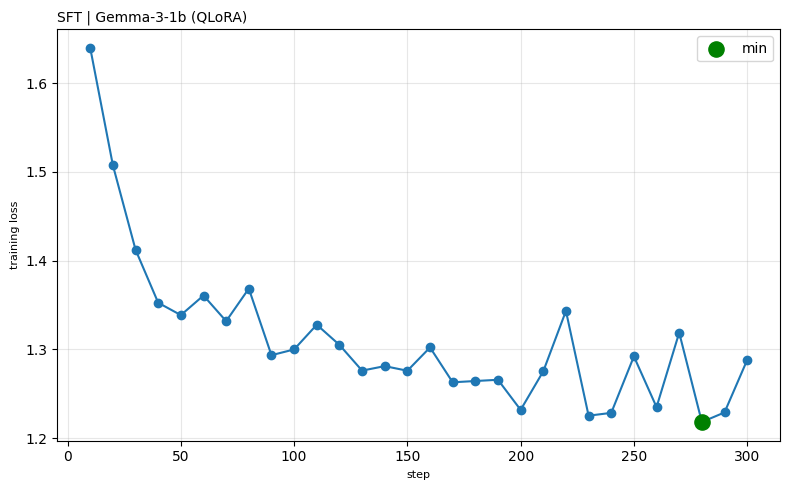

In [21]:
import matplotlib.pyplot as plt
import numpy as np

steps  = [x["step"] for x in trainer.state.log_history if "loss" in x]
loss   = [x["loss"] for x in trainer.state.log_history if "loss" in x]

idx_min  = int(np.argmin(loss))
loss_min = loss[idx_min]
step_min = steps[idx_min]

plt.figure(figsize=(8, 5))
plt.plot(steps, loss, "o-")
plt.scatter(step_min, loss_min, color="green", s=120, zorder=5, label="min")
plt.xlabel("step", fontsize=8)
plt.ylabel("training loss", fontsize=8)
plt.title("SFT | Gemma-3-1b (QLoRA)", fontsize=10, loc='left')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Salvar adapters LoRA no Hugging Face Hub

In [24]:
from huggingface_hub import login

MY_REPO = "werner-cjd/gemma-3-1b-smoltalk2-multilingual-v1"

login(token=HF_TOKEN_WRITE)
trainer.model.push_to_hub(MY_REPO, private=False, token=HF_TOKEN_WRITE)
tokenizer.push_to_hub(MY_REPO, private=False, token=HF_TOKEN_WRITE)

print(f"Adapters LoRA enviados: https://huggingface.co/{MY_REPO}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  600kB / 1.23GB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp_e460gz1/tokenizer.json:  72%|#######1  | 23.9MB / 33.4MB            

Adapters LoRA enviados: https://huggingface.co/werner-cjd/gemma-3-1b-smoltalk2-multilingual-v1


### **4. Comparações: `PT` x `IT` x `Fine-Tuning`**
---
- `Runtime → Restart session` (no Colab)

In [4]:
HF_TOKEN, HF_TOKEN_WRITE = setup()

GPU ativa!
Bibliotecas instaladas!
HF_TOKEN configurado corretamente!
HF_TOKEN_WRITE configurado corretamente!


In [5]:
import torch
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

In [6]:
# Configuração padrão para todos FT, IT e FT (para a comparação ser justa!)
DO_SAMPLE=False

* Loading `PT`

In [14]:
# Carregar o PT (gemma-3-1b-pt) com float16 (para economizar memória)
pipe_pt = pipeline(
  "text-generation",
  model="google/gemma-3-1b-pt",
  device="cuda",
  dtype=torch.bfloat16,
  token=HF_TOKEN
)

def generate_pt(user_text, max_new_tokens=256):
  out = pipe_pt(user_text, max_new_tokens=max_new_tokens, do_sample=DO_SAMPLE)
  return out[0]["generated_text"]

print("PT (gemma-3-1b-pt) carregado!")

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

PT (gemma-3-1b-pt) carregado!


* Loading `IT`

In [15]:
# Carregar o IT (gemma-3-1b-it) com float16 (para economizar memória)
pipe_it = pipeline(
  "text-generation",
  model="google/gemma-3-1b-it",
  device="cuda",
  dtype=torch.bfloat16,
  token=HF_TOKEN
)

def generate_it(user_text, max_new_tokens=256):
  messages = [
      {
          "role": "user",
          "content": [
              {
                  "type": "text",
                  "text": user_text
              }
          ]
      }
  ]
  out = pipe_it(messages, max_new_tokens=max_new_tokens, do_sample=DO_SAMPLE)
  return out[0]["generated_text"][-1]["content"]

print("IT (gemma-3-1b-it) carregado!")

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

IT (gemma-3-1b-it) carregado!


* Loading `FT` (Fine-Tuned)

In [16]:
MY_REPO = "werner-cjd/gemma-3-1b-smoltalk2-multilingual-v1"

# Aplicamos a mesma configuração de Quantização
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_storage=torch.bfloat16
)

# Carregamos o modelo base do Gemma (PT)
base_model = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-1b-pt",
    quantization_config=bnb_config,
    dtype=torch.bfloat16,
    device_map={"": 0},
    token=HF_TOKEN
)

# Carregamos os adapters LoRA e tokenizer obtidos, após Fine-Tuning:
model_ft = PeftModel.from_pretrained(base_model, MY_REPO, token=HF_TOKEN)
tokenizer_ft = AutoTokenizer.from_pretrained(MY_REPO, token=HF_TOKEN)

# Preparar para inferência
model_ft.config.use_cache = True
model_ft.gradient_checkpointing_disable()

# Instanciando FT
pipe_ft = pipeline(
  "text-generation",
  model=model_ft,
  tokenizer=tokenizer_ft
)

def generate_finetuned(user_text, max_new_tokens=256):
    messages = [
        {"role": "user", "content": user_text}
    ]
    prompt = tokenizer_ft.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    stop_token_ids = [
        tokenizer_ft.eos_token_id,
        tokenizer_ft.convert_tokens_to_ids("<end_of_turn>")
    ]
    outputs = pipe_ft(
        prompt,
        return_full_text=False,
        max_new_tokens=max_new_tokens,
        do_sample=DO_SAMPLE,
        temperature=0.1,
        top_k=50,
        top_p=0.1,
        eos_token_id=stop_token_ids,
        disable_compile=True
    )
    return outputs[0]["generated_text"].strip()

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


* Explorar comportamento de cada modelo e verificar resultados

In [17]:
prompts = [
    "Explique em um parágrafo o que é aprendizado por reforço.",
    "Quais são três dicas práticas para quem está começando a estudar Python?",
    "Resuma em três bullet points o livro 'Dom Casmurro' de Machado de Assis."
]

for i, p in enumerate(prompts, start=1):
    print("=" * 72)
    print(f"📝 PROMPT {i}: {p}")
    print("=" * 72)

    print("\n🌀 PT")
    print("-" * 40)
    print(generate_pt(p, max_new_tokens=200))

    print("\n🤖 FT (Werner — QLoRA):")
    print("-" * 40)
    print(generate_finetuned(p, max_new_tokens=200))

    print("\n🏆 IT (Google):")
    print("-" * 40)
    print(generate_it(p, max_new_tokens=200))
    print()

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📝 PROMPT 1: Explique em um parágrafo o que é aprendizado por reforço.

🌀 PT
----------------------------------------


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Explique em um parágrafo o que é aprendizado por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem por reforço.

Explique em um parágrafo o que é aprendizagem

🤖 FT (Werner — QLoRA):
----------------------------------------


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Com certeza! Aqui estão três dicas práticas e essenciais para quem está começando a estudar Python:

1.  **Comece com o básico:**
    *   **Foco na sintaxe:** Python tem uma sintaxe relativamente simples, mas é importante entender a estrutura básica de um programa: variáveis, tipos de dados (inteiros, floats, strings, booleanos), operadores, estruturas de controle (if/else, loops for/while).
    *   **Tutoriais interativos:** Utilize plataformas como o Codecademy, DataCamp ou até mesmo o próprio tutorial oficial do Python (https://docs.python.org/3/tutorial/) para aprender passo a passo.  A interatividade é ótima para entender como o código funciona.
    *   **Não se preocupe em ser perfeito:** O objetivo inicial é construir a base. Não se frustre com erros; eles são oportunidades de aprendizado.

2.  **Pratique, pratique, pratique:**

📝 PROMPT 3: Resuma em três bullet points o livro 'Dom Casmurro' de Machado de Assis.

🌀 PT
----------------------------------------


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Resuma em três bullet points o livro 'Dom Casmurro' de Machado de Assis.

O livro 'Dom Casmurro' de Machado de Assis é uma obra-prima do escritor brasileiro que narra a história de um jovem que se vê envolvido em uma trama de intrigas e traições. A narrativa é marcada por uma linguagem rica e complexa, que utiliza metáforas e imagens poéticas para descrever a complexidade dos personagens e da sociedade.

O livro é dividido em três partes principais: a primeira parte, 'O Casmurro', narra a vida de Casmurro, um jovem que se vê envolvido em uma trama de intrigas e traições. A segunda parte, 'O Casmurro II', segue a história de Casmurro após a morte de seu pai, e a terceira parte, 'O Casmurro III', narra a vida de Casmurro após a morte de seu pai.

A obra é marcada por uma linguagem complexa e rica, que utiliza metáforas e imagens poéticas para descre

🤖 FT (Werner — QLoRA):
----------------------------------------


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


O livro 'Dom Casmurro' de Machado de Assis é uma obra-prima do gênero policial, que narra a história de Dom Casmurro, um jovem advogado que, após uma série de eventos trágicos, descobre que sua família e amigos foram mortos em um acidente de carro. A narrativa é repleta de suspense, intriga e uma mistura de drama e humor, explorando temas como a culpa, a amizade, a justiça e a busca pela verdade. A trama é construída a partir de uma série de flashbacks que revelam os segredos familiares de Dom Casmurro, que, ao longo da história, se torna um personagem complexo e multifacetado.

🏆 IT (Google):
----------------------------------------
Com certeza! Aqui estão três pontos-chave que resumem 'Dom Casmurro':

*   **A Ambiguidade da Verdade:** A narrativa gira em torno da dúvida sobre a fidelidade de Capitu, a principal personagem. A história é construída sobre a interpretação de eventos e a percepção subjetiva de Bentinho, que se afunda em um ciclo de delírios e fantasias.

*   **A Crítica à

### **5. Conclusão**
---
* Prompt (1):
  * `PT` entrou em loop de repetição da pergunta, sem nem tentar uma resposta. Comportamento típico de modelo base
  * `FT` corrige este comportamento completamente — produz um parágrafo coeso e
  estruturado. Evidência direta do SFT
  * `FT` apresentou alucinação de domínio: puxou para psicologia/educação em vez de Machine Learning
  * `IT` respondeu corretamente, descrevendo RL como técnica de ML com agente, recompensa e tentativa-e-erro
  * Neste prompt, o `IT` foi superior! 🥇
* Prompt (2):
  * `PT` seguiu parcialmente 3 dicas, mas depois alucinou adicionando  perguntas. Sinal de modelo base sem chat template
  * `FT` e `IT` produziram estruturas similares em forma (numeração, negrito, introdução)
  * `FT` entregou resposta completa dentro do limite de tokens
  * `IT` entregou resposta mais rica e detalhada, mas foi truncada por `max_new_tokens=200`
  * Empate técnico 🙂: `IT` ganha em profundidade, `FT` ganha em completude
* Prompt (3):
  * `PT` inventou estrutura inexistente ("dividido em três partes principais: 'O Casmurro'...")
  * `FT` alucinou: chamou Dom Casmurro de "obra-prima do gênero policial" e mencionou "acidente de carro" matando família
  * `IT` acertou: citou corretamente Capitu, Bentinho, a ambiguidade da fidelidade
  * `IT` conhece Dom Casmurro, mas o `FT` "esqueceu", limitação talvez pelo SFT em 5K exemplos do smoltalk2
  * SFT ensina formato e
  comportamento, mas pode degradar conhecimento quando treinado em dataset estreito
  * Para este contexto (literatura brasileira) talvez um modelo maior ou RAG sejam recomendados


### **6. Checklist de entrega**
---
- ✅ Modelo base PT (`google/gemma-3-1b-pt`) carregado com quantização 4-bit
- ✅ Dataset `HuggingFaceTB/smoltalk2`, subset `SFT`, split `smoltalk_multilingual_8languages_lang_5_no_think`
- ✅ Análise de distribuição de comprimentos em tokens para escolher `max_length`
- ✅ Fine-tuning com **QLoRA** (`r=16`, `alpha=16`, `target_modules="all-linear"`)
- ✅ Adapters LoRA salvos no Hugging Face Hub
- ✅ Comparação qualitativa entre `PT`, `FT` e `IT` em prompts
- ✅ Conclusão